In [1]:
%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'rpy2'

In [1]:
f1_data <- read.csv("f1-scores.csv")
f1_data

NameError: name 'f1_data' is not defined

In [ ]:
combos <- expand.grid(list(prompt=c("zero-shot","one-shot"),input=c("text","image")), stringsAsFactors=FALSE) 
combos$label <- apply(combos,1,paste,collapse=";")
combos

prompt,input,label
<chr>,<chr>,<chr>
zero-shot,text,zero-shot;text
one-shot,text,one-shot;text
zero-shot,image,zero-shot;image
one-shot,image,one-shot;image


In [ ]:
mnames <- unique(f1_data$model)
f1_mat <- do.call(rbind,lapply(mnames, \(m) {
    vals <- do.call(cbind,lapply(seq_len(nrow(combos)), \(i) {
        combo <- combos[i,]
        with(f1_data,f1[which(model == m & prompt == combo$prompt & input == combo$input)])
    }))
}))
rownames(f1_mat) <- mnames
colnames(f1_mat) <- combos$label
f1_mat

,zero-shot;text,one-shot;text,zero-shot;image,one-shot;image
GPT4.1-mini,63.0,66.6,20.1,21.1
Gemma3-27B,17.2,17.2,51.5,27.5
Llama3-170B,39.9,40.6,NA,NA
Mistral-24B,31.4,30.2,23.4,16.6
NuExtract-4B,27.9,NA,NA,NA
GliNER,6.2,NA,6.2,NA


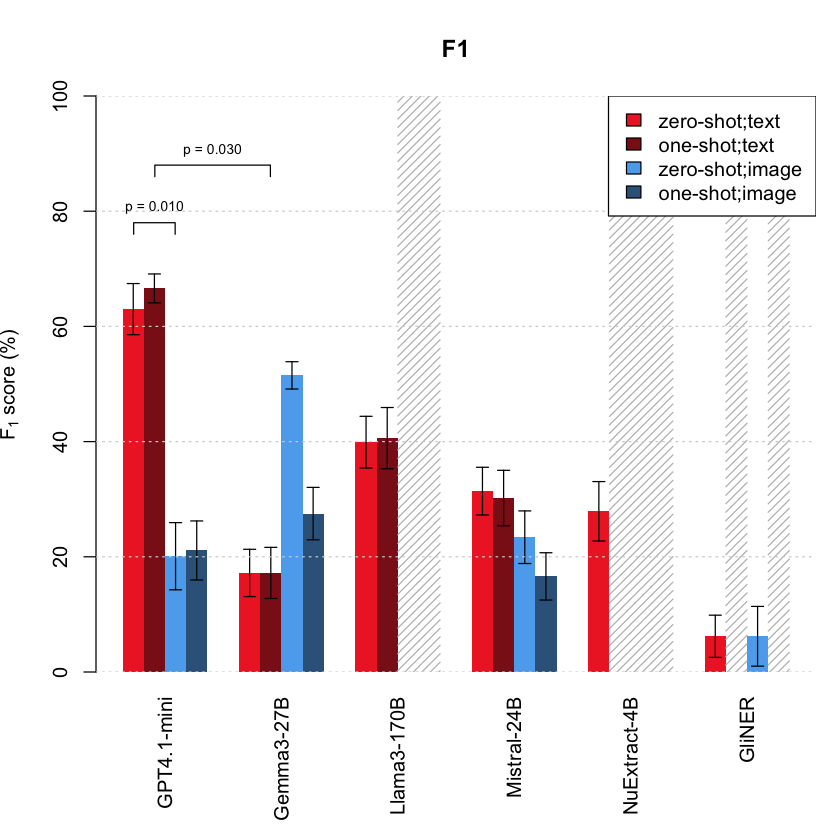

In [ ]:

#make up MOCK error values for now!!! TODO: Replace this with real data
stderr <- matrix(rnorm(6*4,10,2),nrow=4)
pvals <- c(0.03,0.01)

# mycolors <- expand.grid(list(c("firebrick", "darkolivegreen"), c(2,4)))|> apply(1,paste,collapse="")
mycolors <- c("firebrick2", "firebrick4", "steelblue2", "steelblue4")

# options(repr.plot.width = 2, repr.plot.height = 1)

#set margins and axis label orientations
op <- par(las=3, mar=c(7,4,4,1))
#draw plot
xs <- barplot(
    t(f1_mat), beside=TRUE, space=c(0,1.5),
    ylim=c(0,100),
    col=mycolors, border=NA, 
    ylab=expression(F[1]~"score (%)"), main="F1"
)
#draw the error bars
yogitools::errorBars(xs, t(f1_mat), stderr, l=.05)
#determine x-coordinates of missing values
xna <- xs[apply(t(f1_mat),1:2,is.na)]
#add hatching at missing value positions
rect(xna-0.5, 0, xna+0.5, 100, col="gray", density=20,border=NA)
drawPvalBracket(pvals[[1]], xs[2,1], xs[2,2], h = 88, th = 2)
drawPvalBracket(pvals[[2]], xs[1,1], xs[3,1], h = 78, th = 2)
#add grid lines
grid(NA,NULL)
#add legend
legend("topright", colnames(f1_mat), fill=mycolors, bg="white")

par(op)